## Install Libraries

In [12]:
!pip -q install kagglehub[pandas-datasets] openai

#  Import Dataset from source "Kaggle"

In [18]:
#  Import Dataset from source "Kaggle"
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("syedaeman2212/mobile-sales-data")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'mobile-sales-data' dataset.
Path to dataset files: /kaggle/input/mobile-sales-data


In [22]:
# Look at directory Files
import os

print("Files in dataset directory:")
print(os.listdir(path))

Files in dataset directory:
['synthetic_mobile_sales_2025.csv']


In [20]:
# Read the file in directory
df = pd.read_csv(os.path.join(path, "synthetic_mobile_sales_2025.csv"))

df.head()

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025


# Data Summary

In [27]:
# Data Briefing
import numpy as np

def build_data_brief(df):
    brief = {}

    brief["shape"] = df.shape
    brief["columns"] = list(df.columns)
    brief["dtypes"] = df.dtypes.astype(str).to_dict()
    brief["missing"] = df.isnull().sum().to_dict()

    numeric_df = df.select_dtypes(include=[np.number])

    if not numeric_df.empty:
        brief["summary_stats"] = numeric_df.describe().to_dict()
        brief["correlations"] = numeric_df.corr().round(3).to_dict()
    else:
        brief["summary_stats"] = {}
        brief["correlations"] = {}

    return brief

data_brief = build_data_brief(df)

# AI Agent Prompt and analysis

In [40]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [36]:
# Summary Statistics of File

import numpy as np

def build_data_brief(df):
    brief = {}

    brief["shape"] = df.shape
    brief["columns"] = list(df.columns)
    brief["dtypes"] = df.dtypes.astype(str).to_dict()
    brief["missing"] = df.isnull().sum().to_dict()

    numeric_df = df.select_dtypes(include=[np.number])

    if not numeric_df.empty:
        brief["summary_stats"] = numeric_df.describe().to_dict()
        brief["correlations"] = numeric_df.corr().round(3).to_dict()
    else:
        brief["summary_stats"] = {}
        brief["correlations"] = {}

    return brief

data_brief = build_data_brief(df)

In [37]:
# Have the Agent create a summary of the dataset

import json
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    instructions="""
    You are a senior data analyst.
    Analyze the dataset summary provided.
    Provide:
    - Executive summary
    - Key patterns
    - Data quality issues
    - 3 business insights
    - 2 modeling recommendations
    """,
    input=json.dumps(data_brief)[:100000]  # safety limit
)

print(response.output_text)

### Executive Summary
The dataset consists of 500 records with 13 attributes detailing sales information for products across various brands and countries. It includes metrics such as price, sales units, revenue, customer ratings, and payment methods, all recorded for the year 2025. The analysis reveals insights into sales trends, pricing efficacy, and customer sentiment, forming a foundation for strategic business decisions.

### Key Patterns
1. **Sales Distribution**: The average sale price is approximately $889, with units sold averaging around 10. The revenue tends to scale significantly with the quantity sold.
2. **Customer Ratings**: The average customer rating stands at 4.02, indicating generally positive sentiment towards the products sold. However, the variation in ratings suggests there may be discrepancies in product quality or customer preferences across brands/models.
3. **Price-Revenue Relationship**: There is a strong positive correlation (0.544) between price and revenue

In [38]:
# Save File as Markdown

import os
from datetime import datetime

os.makedirs("reports", exist_ok=True)

report_text = response.output_text  # <-- from Step 4
report_path = "reports/ai_data_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"# AI Data Analyst Report\n")
    f.write(f"_Generated: {datetime.now().isoformat()}_\n\n")
    f.write(report_text)

print("Saved:", report_path)

Saved: reports/ai_data_report.md


No missing values chart created (no missing data).


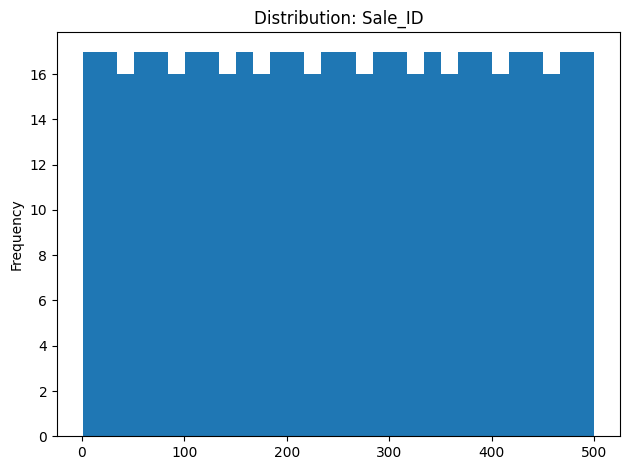

Saved: charts_hist_Sale_ID.png


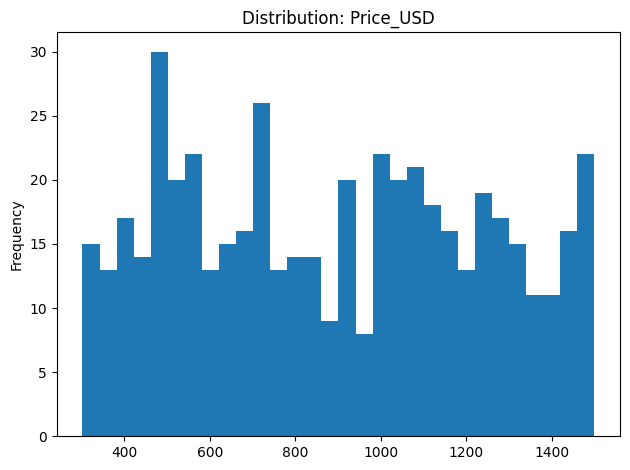

Saved: charts_hist_Price_USD.png


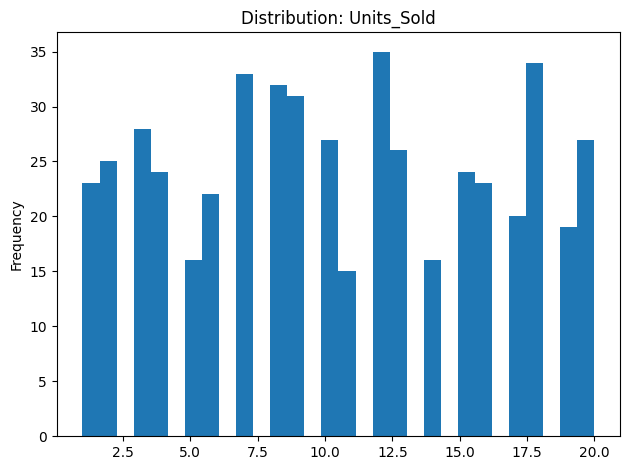

Saved: charts_hist_Units_Sold.png


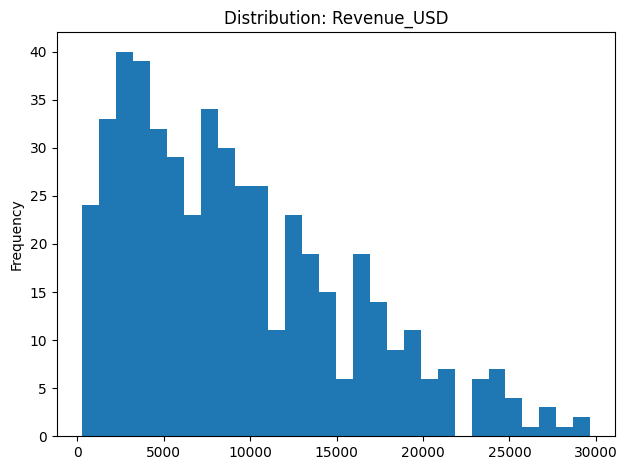

Saved: charts_hist_Revenue_USD.png


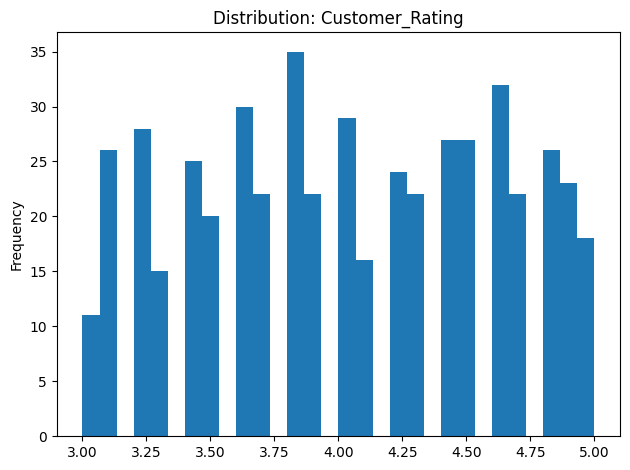

Saved: charts_hist_Customer_Rating.png


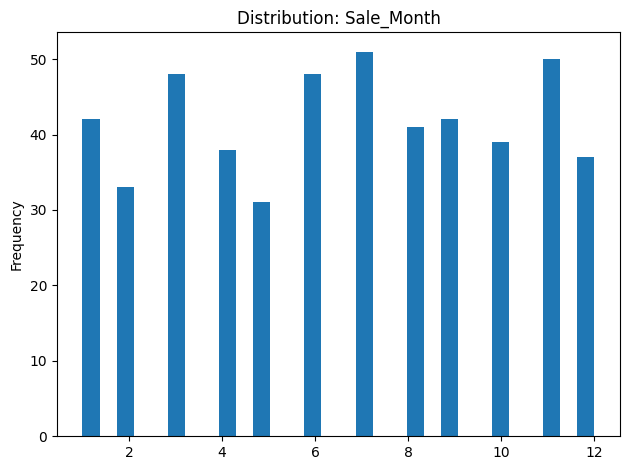

Saved: charts_hist_Sale_Month.png


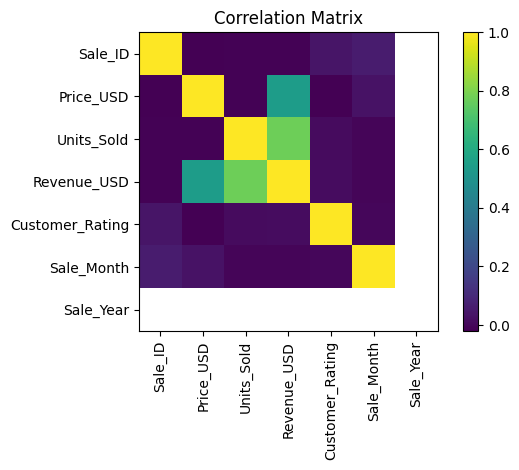

Saved: charts/correlation_matrix.png


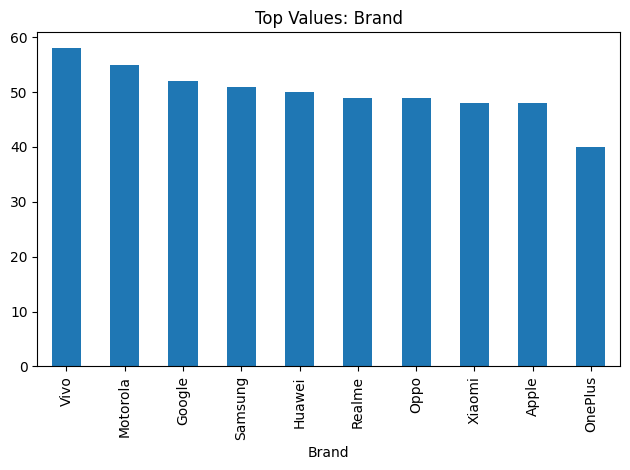

Saved: charts_top_values_Brand.png


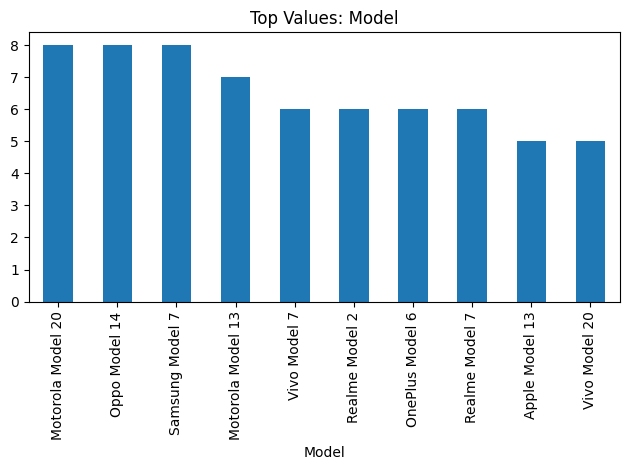

Saved: charts_top_values_Model.png


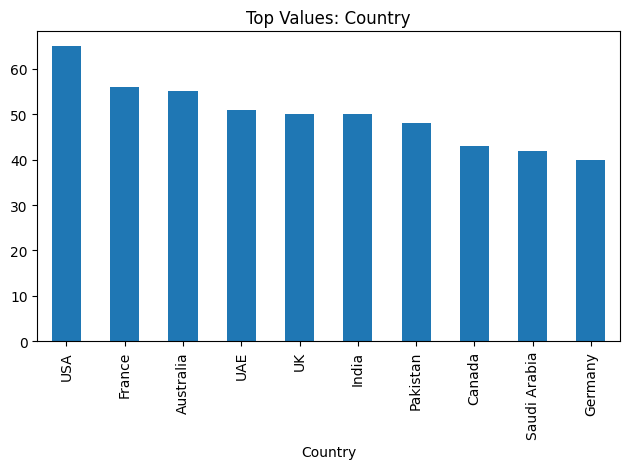

Saved: charts_top_values_Country.png


In [46]:
# EDA univariate and multivariate
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

# 1) Missingness bar (top 20)
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(20)

if len(missing) > 0:
    plt.figure()
    missing.plot(kind="bar")
    plt.title("Top Missing Value Columns")
    plt.tight_layout()
    out = "charts/missing_values_top20.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)
else:
    print("No missing values chart created (no missing data).")

# 2) Numeric distributions (top 6 numeric cols)
num_df = df.select_dtypes(include=[np.number])
for col in list(num_df.columns)[:6]:
    plt.figure()
    num_df[col].dropna().plot(kind="hist", bins=30)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    out = f"charts/hist_{col}.png".replace("/", "_")
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# 3) Correlation heatmap (only if not too many numeric cols)
if 2 <= num_df.shape[1] <= 25:
    corr = num_df.corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr)
    plt.title("Correlation Matrix")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.tight_layout()
    out = "charts/correlation_matrix.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)
else:
    print("Skipped correlation heatmap (need 2–25 numeric columns).")

# 4) Top category bars (up to 3 categorical columns)
cat_cols = list(df.select_dtypes(exclude=[np.number]).columns)
for col in cat_cols[:3]:
    vc = df[col].astype("string").value_counts(dropna=False).head(10)
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Top Values: {col}")
    plt.tight_layout()
    out = f"charts/top_values_{col}.png".replace("/", "_")
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

In [47]:
# Clean Dataset
import numpy as np
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

clean_df = df.copy()

# 1) Drop exact duplicate rows
clean_df = clean_df.drop_duplicates()

# 2) Normalize column names (great for downstream work)
clean_df.columns = (
    clean_df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
                  .str.replace(r"[^a-z0-9_]", "", regex=True)
)

# 3) Handle missing values:
# - numeric: median
# - categorical: mode (or "unknown" if empty)
for col in clean_df.columns:
    if pd.api.types.is_numeric_dtype(clean_df[col]):
        med = clean_df[col].median()
        clean_df[col] = clean_df[col].fillna(med)
    else:
        mode = clean_df[col].mode(dropna=True)
        fill_val = mode.iloc[0] if len(mode) else "unknown"
        clean_df[col] = clean_df[col].fillna(fill_val)

clean_path = "data/cleaned_data.csv"
clean_df.to_csv(clean_path, index=False)
print("Saved cleaned dataset:", clean_path)
print("Clean shape:", clean_df.shape)

Saved cleaned dataset: data/cleaned_data.csv
Clean shape: (500, 13)
